
# 🌲 Day 25: Random Forest — Complete Theory Notebook

---

This notebook is designed as a **deep learning resource** for understanding Random Forest from **first principles to advanced intuition**.

We will not just learn *what*, but *why* and *how*.

---




# 🌳 1. Random Forest — Beginner Friendly Understanding

---

### 🧠 Explanation

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their outputs to improve accuracy and reduce overfitting. Instead of relying on a single tree (which can be unstable), Random Forest creates a “forest” of trees, each trained on slightly different data.

The key idea is **wisdom of crowds** — individual trees may make mistakes, but together they produce a more robust prediction.

---

### 📐 Formula

For classification:

Final Prediction = **Majority Vote of Trees**

\[
\hat{y} = mode(T_1(x), T_2(x), ..., T_n(x))
\]

For regression:

\[
\hat{y} = \frac{1}{n} \sum_{i=1}^{n} T_i(x)
\]

---

### 🌍 Real-Life Use Case

In fraud detection (Banking/BFSI), different trees may capture different fraud patterns. One tree might focus on transaction size, another on location, another on time patterns. Together, they create a more reliable fraud detection system.

---

### ⚠️ Limitation

Random Forest models are harder to interpret compared to a single decision tree. You lose transparency.

---

### 🔄 Comparison

- Decision Tree → High variance
- Random Forest → Reduced variance
- Boosting → Reduces bias

---

### 💻 Hands-on


In [13]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = RandomForestClassifier(n_estimators=100)
model.fit(X, y)

print(model.predict(X[75:85]))
print(y[75:85])

[1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1]



# 🌲 2. Bootstrap Sampling & Final Voting

---

### 🧠 Explanation

Random Forest uses **bootstrap sampling**, meaning each tree is trained on a randomly sampled dataset (with replacement). This ensures diversity among trees.

Once all trees are trained, predictions are combined using **voting (classification)** or **averaging (regression)**.

This reduces variance because errors from different trees cancel out.

---

### 📐 Formula

Bootstrap sample size = N (same as dataset, but sampled with replacement)

Voting:

\[
Final = mode(predictions)
\]

---

### 🌍 Real-Life Use Case

In medical diagnosis, different models trained on slightly different patient data subsets can reduce bias and improve reliability.

---

### ⚠️ Limitation

If all trees become similar (low diversity), the benefit of ensemble reduces.

---

### 🔄 Comparison

- Bagging → Uses bootstrap
- Boosting → Sequential learning
- Voting → Combines independent models

---

### 💻 Hands-on


In [18]:

import numpy as np

data = np.arange(10)

# bootstrap sampling
sample1 = np.random.choice(data, size=10, replace=True)
print("Bootstrap Sample:", sample1)

sample2 = np.random.choice(data, size=10, replace=True)
print("Bootstrap Sample:", sample2)

Bootstrap Sample: [6 4 2 1 5 0 0 1 3 7]
Bootstrap Sample: [9 8 8 4 1 3 7 2 4 1]



# 🤝 3. Ensemble Learning — Bagging, Boosting, Stacking, Voting

---

### 🧠 Explanation

Ensemble methods combine multiple models to improve performance.

- **Bagging** → Parallel models (Random Forest)
- **Boosting** → Sequential correction (XGBoost)
- **Stacking** → Meta-model combines outputs
- **Voting** → Simple averaging

Random Forest specifically uses **Bagging**.

---

### 📐 Formula

Bagging:

\[
f(x) = \frac{1}{B} \sum_{b=1}^{B} f_b(x)
\]

---

### 🌍 Real-Life Use Case

In credit scoring, combining multiple models reduces risk of incorrect approval decisions.

---

### ⚠️ Limitation

Ensemble models increase computational cost.

---

### 🔄 Comparison

- Bagging → reduces variance
- Boosting → reduces bias
- Stacking → combines strengths

---

### 💻 Hands-on


In [19]:

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200)),
        ('dt', DecisionTreeClassifier())
    ],
    voting='hard'
)

model.fit(X, y)
print(model.predict(X[:5]))


[0 0 0 0 0]



# 🎯 4. Random Feature Selection

---

### 🧠 Explanation

At each split, Random Forest considers only a **random subset of features**. This ensures trees are not identical.

This introduces diversity and reduces correlation between trees.

---

### 📐 Formula

Number of features considered:

\[
m = \sqrt{p} \quad (classification)
\]

\[
m = \frac{p}{3} \quad (regression)
\]

---

### 🌍 Real-Life Use Case

In customer churn prediction, different trees focus on different attributes like usage, billing, demographics.

---

### ⚠️ Limitation

Too few features → weak trees  
Too many features → less randomness

---

### 🔄 Comparison

- Decision Tree → uses all features
- Random Forest → uses subset

---

### 💻 Hands-on


In [20]:

model = RandomForestClassifier(max_features='sqrt')
model.fit(X, y)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



# 📊 5. Out-of-Bag (OOB) Error

---

### 🧠 Explanation

Since bootstrap sampling leaves out ~1/3 of data, this unused data is called **Out-of-Bag data**.

We can use OOB data as validation, eliminating need for separate validation set.

---

### 📐 Formula

OOB Error:

\[
Error = \frac{1}{N} \sum I(y_i \neq \hat{y}_i)
\]

---

### 🌍 Real-Life Use Case

Useful in production systems where data is limited and splitting reduces training data.

---

### ⚠️ Limitation

Not as robust as cross-validation in small datasets.

---

### 🔄 Comparison

- OOB → built-in validation
- CV → external validation

---

### 💻 Hands-on


In [21]:

model = RandomForestClassifier(oob_score=True)
model.fit(X, y)

print("OOB Score:", model.oob_score_)


OOB Score: 0.94


# 🏗️ Stacking (Stacked Generalization) — Learning How Models Learn from Each Other

---

## 🧠 Intuition First (Think Like a Real System)

In most machine learning systems, different models are good at **different types of patterns**.

- A linear model might capture **simple relationships**
- A tree-based model might capture **non-linear rules**
- A complex model might capture **deep interactions**

Now the question becomes:

👉 *Can we intelligently combine these models instead of treating them equally?*

This is where **Stacking** comes in.

---

## ⚙️ What is Stacking?

Stacking is an **ensemble learning technique** where:

1. Multiple base models (Level 1 models) are trained on the same dataset  
2. Their predictions are used as **inputs (features)**  
3. A new model (Level 2 or Meta Model) is trained on these predictions  

👉 The meta-model learns **which model to trust and when**

---

## 🏗️ Architecture of Stacking

### 🔹 Level 1: Base Models

These models learn patterns independently:

- Logistic Regression  
- Decision Tree  
- Random Forest  

Each model produces predictions like:

| Sample | LR | DT | RF |
|--------|----|----|----|
| 1      | 0  | 1  | 1  |
| 2      | 1  | 1  | 0  |

---

### 🔹 Level 2: Meta Model

Now we train a second model using the above predictions:

| LR | DT | RF | Final Output |
|----|----|----|--------------|
| 0  | 1  | 1  | 1            |
| 1  | 1  | 0  | 1            |

👉 This model learns patterns like:
- “If DT and RF agree → trust them”
- “If LR disagrees → ignore it in some cases”

---

## 📐 Mathematical View

Let:

- Base models = \( f_1(x), f_2(x), ..., f_n(x) \)

Then meta-model learns:

\[
\hat{y} = g(f_1(x), f_2(x), ..., f_n(x))
\]

Where:
- \( g \) = meta-model  
- Inputs = predictions of base models  

---

## 🌍 Real-Life Use Case (Fraud Detection)

Imagine a banking system:

- Model 1 → good at detecting small fraud patterns  
- Model 2 → good at detecting large transactions  
- Model 3 → good at behavioral anomalies  

👉 Stacking learns:
- Which model works best under which condition  
- Combines them intelligently instead of blindly voting  

---

## ⚠️ Important Detail (Very Crucial)

If we directly train meta-model on training predictions → **data leakage happens**

👉 Solution:
- Use **cross-validation predictions** to train meta-model  

This ensures:
- Meta-model sees **unseen predictions**
- System remains **generalizable**

---

## 🔄 Stacking vs Voting (Key Difference)

| Concept | Voting | Stacking |
|--------|--------|----------|
| Decision logic | Majority / average | Learned |
| Meta-model | ❌ No | ✅ Yes |
| Intelligence | Low | High |
| Flexibility | Limited | Very high |

---

## 💻 Hands-on Example

```python
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier()),
        ('lr', LogisticRegression())
    ],
    final_estimator=LogisticRegression()
)

model.fit(X_train, y_train)
pred = model.predict(X_test)


# ⚙️ 6. Hyperparameters Deep Dive

---

### 🧠 Explanation

Hyperparameters control how Random Forest behaves.

- n_estimators → number of trees
- max_depth → tree depth
- min_samples_split → minimum samples to split
- min_samples_leaf → minimum samples in leaf
- max_features → feature subset
- bootstrap → sampling method

---

### 📐 Formula Insight

More trees:

\[
Error \downarrow \quad as \quad n \uparrow
\]

(but plateaus after some point)

---

### 🌍 Real-Life Use Case

In fraud detection, deeper trees capture complex patterns but risk overfitting.

---

### ⚠️ Limitation

Too many trees → slow  
Too deep → overfitting

---

### 🔄 Comparison

- Shallow trees → low variance
- Deep trees → high variance

---

### 💻 Hands-on


In [24]:

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4
)

model.fit(X, y)


,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



# ⚖️ 7. Advantages & Limitations

---

### 🧠 Explanation

Random Forest balances bias and variance effectively, making it one of the most widely used algorithms.

---

### 🌍 Real-Life Use Case

Used in recommendation systems, fraud detection, healthcare diagnostics.

---

### ⚠️ Limitations

- Hard to interpret
- Large models
- Slower prediction vs single tree

---

### 🔄 Comparison

- Linear Models → interpretable
- Random Forest → powerful but complex
- Boosting → more accurate but sensitive

---

### 💻 Hands-on


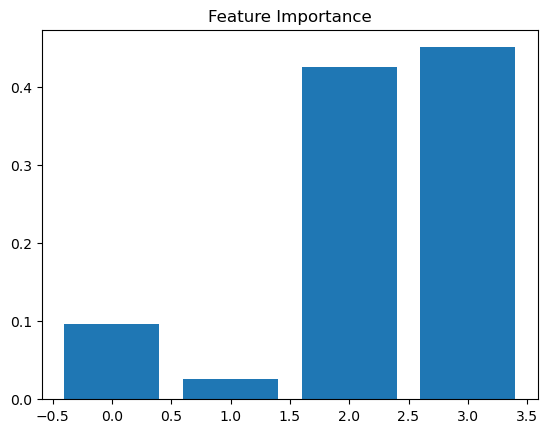

In [25]:

import matplotlib.pyplot as plt


model = RandomForestClassifier()
model.fit(X, y)

plt.bar(range(len(model.feature_importances_)), model.feature_importances_)
plt.title("Feature Importance")
plt.show()


Step 1: Setup & Data

In [26]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

Create "Industry-like" Dataset

In [27]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[0.95, 0.05],  # Fraud is rare
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Step 2: Understand Bootstrap (Core of Random Forest)

In [28]:
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    X_sample = X[indices]
    y_sample = y[indices]
    
    oob_mask = np.ones(n_samples, dtype=bool)
    oob_mask[indices] = False
    
    X_oob = X[oob_mask]
    y_oob = y[oob_mask]
    
    return X_sample, y_sample, X_oob, y_oob

Run Bootstrap

In [29]:
X_sample, y_sample, X_oob, y_oob = bootstrap_sample(X_train, y_train)

print("Training sample size:", X_sample.shape)
print("OOB sample size:", X_oob.shape)

Training sample size: (8000, 20)
OOB sample size: (2969, 20)


Manual Bagging Implementation

In [30]:
from sklearn.tree import DecisionTreeClassifier

n_trees = 10
trees = []
oob_scores = []

for i in range(n_trees):
    
    # Step 1: Bootstrap sampling
    X_sample, y_sample, X_oob, y_oob = bootstrap_sample(X_train, y_train)
    
    # Step 2: Train decision tree
    tree = DecisionTreeClassifier(max_features="sqrt", random_state=i)
    tree.fit(X_sample, y_sample)
    
    trees.append(tree)
    
    # Step 3: OOB evaluation
    if len(X_oob) > 0:
        oob_pred = tree.predict(X_oob)
        score = np.mean(oob_pred == y_oob)
        oob_scores.append(score)

print("Average OOB Score:", np.mean(oob_scores))

Average OOB Score: 0.9391411557044484


Step 4: Final Voting (Core Ensemble Logic)

In [31]:
def predict_forest(trees, X):
    predictions = np.array([tree.predict(X) for tree in trees])
    
    # Majority voting
    final_predictions = np.apply_along_axis(
        lambda x: np.bincount(x).argmax(),
        axis=0,
        arr=predictions
    )
    
    return final_predictions

Test Predictions

In [32]:
y_pred_manual = predict_forest(trees, X_test)

print(classification_report(y_test, y_pred_manual))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1892
           1       0.94      0.42      0.58       108

    accuracy                           0.97      2000
   macro avg       0.95      0.71      0.78      2000
weighted avg       0.97      0.97      0.96      2000



Step 5: Now Compare with Sklearn Random Forest

In [33]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

Step 6: Industry-Level Evaluation

In [34]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("OOB Score:", rf.oob_score_)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1892
           1       0.77      0.63      0.69       108

    accuracy                           0.97      2000
   macro avg       0.88      0.81      0.84      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9329388849737686
OOB Score: 0.96675


Step 7: Feature Importance (Business Insight)

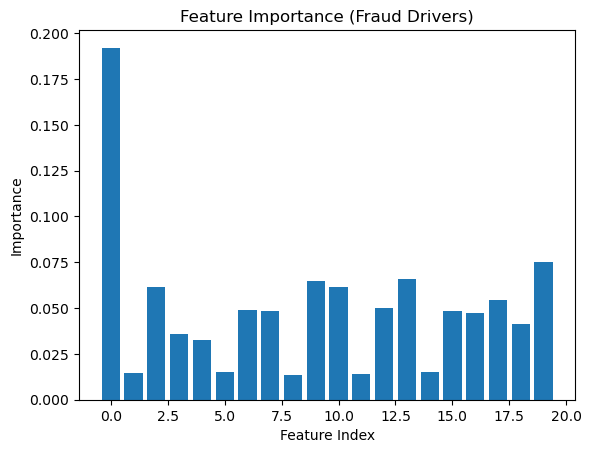

In [35]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Fraud Drivers)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

Step 8: Hyperparameter Tuning (Production Style)

In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced"),
    param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None}
